<a href="https://colab.research.google.com/github/viratk8861-cyber/aaaaa/blob/main/mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ls -l

total 8
drwx------ 5 root root 4096 Jun 30 03:43 drive/
drwxr-xr-x 1 root root 4096 Jun  4 13:39 sample_data/


In [ ]:
cd drive/MyDrive/mca-aiml/

/content/drive/MyDrive/mca-aiml


In [ ]:
ls -l

total 20
drwx------ 2 root root 4096 Jun 30 03:20 data/
drwx------ 2 root root 4096 Jun 30 03:20 models/
drwx------ 2 root root 4096 Jun 30 03:20 notebooks/
drwx------ 2 root root 4096 Jun 30 03:20 outputs/
drwx------ 2 root root 4096 Jun 30 03:20 src/


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", plt.matplotlib.__version__)

print("\nAll specified data analysis packages are successfully imported.")

Pandas version: 2.2.2
NumPy version: 2.0.2
Matplotlib version: 3.10.0

All specified data analysis packages are successfully imported.


In [ ]:
import os
folders = [
    "data",
    "notebooks",
    "src",
    "models",
    "outputs"
]

for folder in folders:
    os.makedirs(
        os.path.join("/content/drive/MyDrive/mca-aiml/", folder),
        exist_ok=True
    )

print("All folders created.")

All folders created.


In [ ]:
!git --version

git version 2.34.1


In [ ]:
!git config --global user.name "viratk8861-cyber"
!git config --global user.email "virat.k8861@gmail.com"

In [ ]:
!git config --list

filter.lfs.process=git-lfs filter-process
filter.lfs.required=true
filter.lfs.clean=git-lfs clean -- %f
filter.lfs.smudge=git-lfs smudge -- %f
user.name=viratk8861-cyber
user.email=virat.k8861@gmail.com
core.repositoryformatversion=0
core.filemode=true
core.bare=false
core.logallrefupdates=true


In [ ]:
!git init

Reinitialized existing Git repository in /content/drive/MyDrive/mca-aiml/.git/


In [ ]:
cd ..

/


In [ ]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", X_test.shape)
print("Testing Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Testing Images: (10000, 28, 28)
Testing Labels: (10000,)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=1,
    batch_size=32,
    validation_data=(X_test, y_test)
)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9353 - loss: 0.2079 - val_accuracy: 0.9840 - val_loss: 0.0501


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9840 - loss: 0.0501
Test Loss: 0.0500890351831913
Test Accuracy: 0.984000027179718


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
7


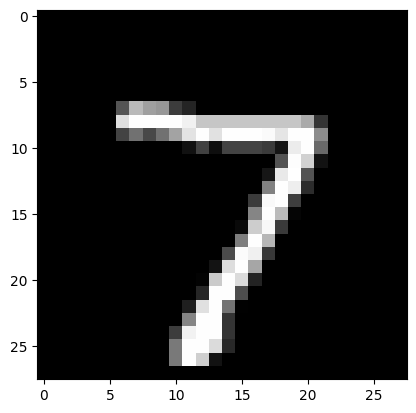

In [ ]:
prediction = model.predict(X_test)

print(np.argmax(prediction[0]))
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Define Architecture
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model defined and compiled successfully.")

Model defined and compiled successfully.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Digit: 7


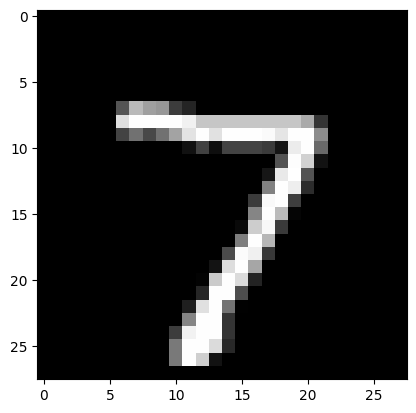

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure 'model' and 'X_test' are defined by running previous cells first
try:
    prediction = model.predict(X_test)

    print(f"Predicted Digit: {np.argmax(prediction[0])}")
    plt.imshow(X_test[0].reshape(28,28), cmap='gray')
    plt.show()
except NameError as e:
    print(f"Error: {e}. Please run the cells that define 'model' and 'X_test' first.")

In [ ]:
from tensorflow.keras.datasets import mnist

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalize pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape data to include the channel dimension (needed for Conv2D layers)
# (Samples, Height, Width, Channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print("Data loaded and preprocessed successfully.")

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)
Data loaded and preprocessed successfully.
